# Finland Population Analysis and Machine Learning Forecast

This notebook follows the following workflow:

- load the official Finland population CSV
- clean and reshape the data
- visualize the national population trend
- train a machine learning model
- forecast 2030–2040
- analyze regional growth
- detect anomalies
- cluster regions by population and growth
- export final CSV files for reporting

## Dataset information

This project uses the Statistics Finland population table for **1990–2025**.

The source file contains population values for many Finnish areas and years.
The notebook converts the source data into a clean long-format dataset that is easier to analyze and visualize.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from io import StringIO

from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Find the source CSV automatically

This cell looks for a file that starts with:

`001_11ra_2025_20260425-094626`

That makes the notebook easier to run in both **VS Code** and **CSC** as long as the CSV is in the same folder.

In [3]:
csv_candidates = sorted(Path(".").glob("001_11ra_2025_20260425-094626*.csv"))
cleaned_fallback = Path("finland_population_student_cleaned.csv")

if csv_candidates:
    RAW_CSV_PATH = csv_candidates[0]
    RAW_CSV_IS_RAW = True
elif cleaned_fallback.exists():
    RAW_CSV_PATH = cleaned_fallback
    RAW_CSV_IS_RAW = False
else:
    raise FileNotFoundError(
        "Source CSV not found. Put the raw Statistics Finland CSV or finland_population_student_cleaned.csv in the same folder as this notebook."
    )

RAW_CSV_PATH

WindowsPath('finland_population_student_cleaned.csv')

## Load the raw dataset correctly

The source CSV has a title line before the real header, so this step removes the first line and loads the actual table.

In [ ]:
raw_bytes = RAW_CSV_PATH.read_bytes()

used_encoding = None
for enc in ["cp1252", "latin1", "iso-8859-1", "utf-8-sig", "utf-16"]:
    try:
        raw_text = raw_bytes.decode(enc)
        used_encoding = enc
        break
    except UnicodeDecodeError:
        continue

if used_encoding is None:
    raise ValueError("Could not decode the source CSV with common encodings.")

lines = [line for line in raw_text.splitlines() if line.strip() != ""]
if RAW_CSV_IS_RAW:
    body_text = "\n".join(lines[1:])
else:
    body_text = "\n".join(lines)

from io import StringIO
import pandas as pd

df = pd.read_csv(StringIO(body_text))

print("Encoding used:", used_encoding)
df.head()
print("Shape:", df.shape)

Encoding used: cp1252
Shape: (568, 38)


,Alue,Tiedot,1990,1991,1992,1993,1994,1995,1996,1997,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,KOKO MAA,Väestö 31.12.,4998478,5029002,5054982,5077912,5098754,5116826,5132320,5147349,...,5503297,5513130,5517919,5525292,5533793,5548241,5563970,5603851,5635971,5652881
1,Akaa,Väestö 31.12.,16048,16096,16201,16142,16038,15986,15924,15840,...,16923,16769,16611,16475,16391,16467,16473,16405,16387,16429
2,Alajärvi,Väestö 31.12.,11963,11982,12023,11992,11985,11890,11874,11803,...,9899,9831,9700,9562,9419,9311,9183,9113,9078,8982
3,Alavieska,Väestö 31.12.,3072,3060,3053,3097,3084,3051,3054,3064,...,2639,2610,2573,2519,2517,2491,2447,2437,2410,2384
4,Alavus,Väestö 31.12.,13785,13781,13744,13690,13623,13472,13341,13330,...,11907,11713,11544,11468,11332,11197,11102,10933,10780,10634


## Rename and clean columns

In this step:

- `Alue` becomes `Region`
- `Tiedot` becomes `Indicator`
- only `Väestö 31.12.` is kept

In [ ]:
df = df.rename(columns={
    "Alue": "Region",
    "Tiedot": "Indicator"
})

df = df[df["Indicator"] == "Väestö 31.12."].copy()
df.head()

,Region,Indicator,1990,1991,1992,1993,1994,1995,1996,1997,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,KOKO MAA,Väestö 31.12.,4998478,5029002,5054982,5077912,5098754,5116826,5132320,5147349,...,5503297,5513130,5517919,5525292,5533793,5548241,5563970,5603851,5635971,5652881
1,Akaa,Väestö 31.12.,16048,16096,16201,16142,16038,15986,15924,15840,...,16923,16769,16611,16475,16391,16467,16473,16405,16387,16429
2,Alajärvi,Väestö 31.12.,11963,11982,12023,11992,11985,11890,11874,11803,...,9899,9831,9700,9562,9419,9311,9183,9113,9078,8982
3,Alavieska,Väestö 31.12.,3072,3060,3053,3097,3084,3051,3054,3064,...,2639,2610,2573,2519,2517,2491,2447,2437,2410,2384
4,Alavus,Väestö 31.12.,13785,13781,13744,13690,13623,13472,13341,13330,...,11907,11713,11544,11468,11332,11197,11102,10933,10780,10634


## Convert the data from wide format to long format

This step makes the dataset much easier to analyze.

In [ ]:
year_columns = [col for col in df.columns if str(col).isdigit()]

df_long = df.melt(
    id_vars=["Region", "Indicator"],
    value_vars=year_columns,
    var_name="Year",
    value_name="Population"
)

df_long["Year"] = df_long["Year"].astype(int)
df_long["Population"] = pd.to_numeric(df_long["Population"], errors="coerce")

df_long = df_long.sort_values(["Region", "Year"]).reset_index(drop=True)
df_long.head()

,Region,Indicator,Year,Population
0,Akaa,Väestö 31.12.,1990,16048
1,Akaa,Väestö 31.12.,1991,16096
2,Akaa,Väestö 31.12.,1992,16201
3,Akaa,Väestö 31.12.,1993,16142
4,Akaa,Väestö 31.12.,1994,16038


## Add analysis columns and export the final cleaned dataset

This creates a ready-to-use final CSV for your report and notebook work.

In [ ]:
df_long["Growth Rate"] = df_long.groupby("Region")["Population"].pct_change()
df_long["Growth Change"] = df_long.groupby("Region")["Growth Rate"].diff()

growth_mean = df_long["Growth Change"].mean(skipna=True)
growth_std = df_long["Growth Change"].std(skipna=True)

df_long["Anomaly"] = (df_long["Growth Change"] - growth_mean).abs() > 3 * growth_std

final_csv_path = Path("finland_population_final_analysis.csv")
df_long.to_csv(final_csv_path, index=False)

print("Saved final cleaned dataset to:", final_csv_path.resolve())
df_long.head()

Saved final cleaned dataset to: C:\Users\mazum\Downloads\finland_population_final_analysis.csv


,Region,Indicator,Year,Population,Growth Rate,Growth Change,Anomaly
0,Akaa,Väestö 31.12.,1990,16048,NaN,NaN,False
1,Akaa,Väestö 31.12.,1991,16096,0.002991,NaN,False
2,Akaa,Väestö 31.12.,1992,16201,0.006523,0.003532,False
3,Akaa,Väestö 31.12.,1993,16142,-0.003642,-0.010165,False
4,Akaa,Väestö 31.12.,1994,16038,-0.006443,-0.002801,False


## Select Finland total population

`KOKO MAA` means the whole country.

In [ ]:
country = df_long[df_long["Region"] == "KOKO MAA"].copy()
country.head()

,Region,Indicator,Year,Population,Growth Rate,Growth Change,Anomaly
5400,KOKO MAA,Väestö 31.12.,1990,4998478,NaN,NaN,False
5401,KOKO MAA,Väestö 31.12.,1991,5029002,0.006107,NaN,False
5402,KOKO MAA,Väestö 31.12.,1992,5054982,0.005166,-0.000941,False
5403,KOKO MAA,Väestö 31.12.,1993,5077912,0.004536,-0.000630,False
5404,KOKO MAA,Väestö 31.12.,1994,5098754,0.004104,-0.000432,False


## Plot the actual Finland population trend

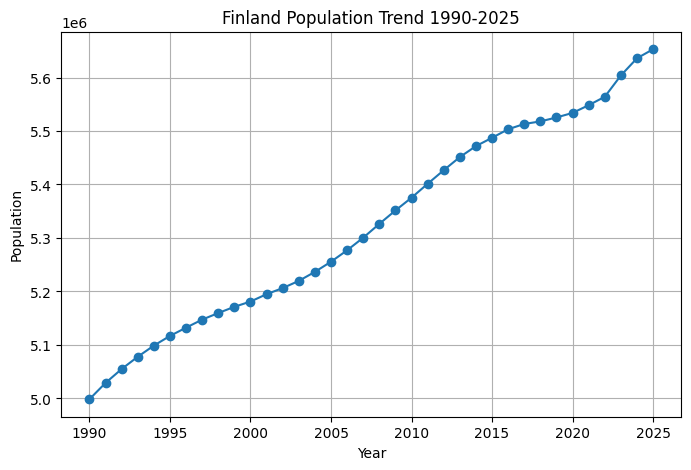

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(country["Year"], country["Population"], marker="o")
plt.title("Finland Population Trend 1990-2025")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()

The national population trend shows a long-term increase from 1990 to 2025.

## Prepare the data for the machine learning model

- `Year` is the input
- `Population` is the target
- both are scaled before training

In [ ]:
X = country["Year"].values.astype(float)
y = country["Population"].values.astype(float)

X_mean = X.mean()
X_std = X.std()
X_scaled = ((X - X_mean) / X_std).reshape(-1, 1)

y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

## Build the neural network model

In [ ]:
model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    max_iter=3000,
    random_state=42
)
model

,loss,'squared_error'
,hidden_layer_sizes,"(16,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,3000
,shuffle,True


## Train the model

In [ ]:
model.fit(X_scaled, y_scaled)

,loss,'squared_error'
,hidden_layer_sizes,"(16,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,3000
,shuffle,True


## Evaluate the model on historical data

In [ ]:
train_preds = model.predict(X_scaled)

loss = np.mean((train_preds - y_scaled) ** 2)
mae = np.mean(np.abs(train_preds - y_scaled))

print("Loss:", loss)
print("MAE (scaled):", mae)

Loss: 0.01707506806203566
MAE (scaled): 0.1031003282584641


## Predict future population for 2030–2040

In [ ]:
future_years = np.arange(2030, 2041)
future_scaled = ((future_years - X_mean) / X_std).reshape(-1, 1)

future_preds_scaled = model.predict(future_scaled)
future_preds = future_preds_scaled * y_std + y_mean

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Predicted Population": future_preds.astype(int)
})

forecast_csv_path = Path("finland_population_forecast_2030_2040.csv")
forecast_df.to_csv(forecast_csv_path, index=False)

print("Saved forecast CSV to:", forecast_csv_path.resolve())
forecast_df

Saved forecast CSV to: C:\Users\mazum\Downloads\finland_population_forecast_2030_2040.csv


,Year,Predicted Population
0,2030,5743041
1,2031,5761029
2,2032,5779017
3,2033,5797004
4,2034,5814992
5,2035,5832980
6,2036,5850968
7,2037,5868956
8,2038,5886943
9,2039,5904931


## Plot actual data and forecast together

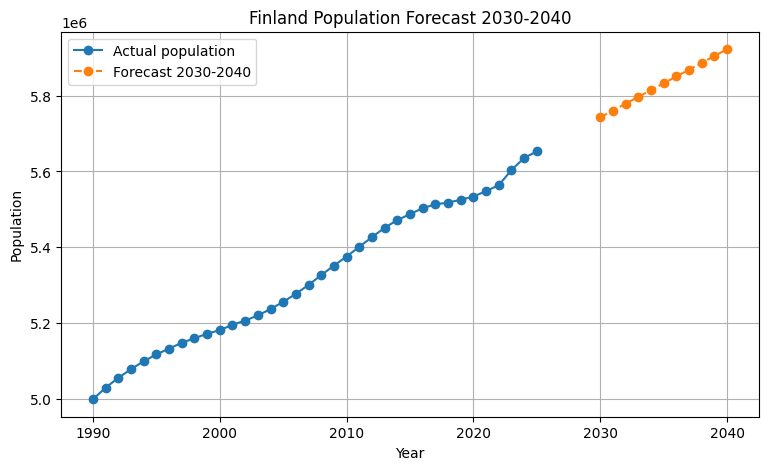

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    country["Year"],
    country["Population"],
    marker="o",
    label="Actual population"
)

plt.plot(
    forecast_df["Year"],
    forecast_df["Predicted Population"],
    marker="o",
    linestyle="--",
    label="Forecast 2030-2040"
)

plt.title("Finland Population Forecast 2030-2040")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

## Analyze population growth by region

This uses the average annual growth rate for each region in the dataset.

In [ ]:
growth_summary = (
    df_long.groupby("Region")["Growth Rate"]
    .mean()
    .sort_values(ascending=False)
)

print("Top growing regions:")
print(growth_summary.head(10))

print("\nMost declining regions:")
print(growth_summary.tail(10))

Top growing regions:
Region
Liminka                  0.021624
Kempele                  0.020176
Jomala                   0.018910
Espoo                    0.018315
Pirkkala                 0.018166
TA01 Espoo-Kauniainen    0.017921
Lempäälä                 0.015632
Lemland                  0.015104
Kirkkonummi              0.014349
Vantaa                   0.014113
Name: Growth Rate, dtype: float64

Most declining regions:
Region
Rautjärvi    -0.017756
Ilomantsi    -0.017783
Siikainen    -0.018293
Posio        -0.018693
Salla        -0.018718
Rääkkylä     -0.018755
Puolanka     -0.019439
Kivijärvi    -0.019529
Hyrynsalmi   -0.020253
Rautavaara   -0.021327
Name: Growth Rate, dtype: float64


## Detect unusual population changes

This flags rows where the change in growth is far from the average.

In [ ]:
anomalies = df_long[df_long["Anomaly"]].copy()
anomalies.head(20)

,Region,Indicator,Year,Population,Growth Rate,Growth Change,Anomaly
218,Aura,Väestö 31.12.,1992,3195,0.019464,-0.039320,True
258,Brändö,Väestö 31.12.,1996,534,-0.025547,-0.029210,True
259,Brändö,Väestö 31.12.,1997,538,0.007491,0.033038,True
260,Brändö,Väestö 31.12.,1998,525,-0.024164,-0.031654,True
264,Brändö,Väestö 31.12.,2002,502,0.001996,0.027288,True
270,Brändö,Väestö 31.12.,2008,518,0.015686,0.034917,True
271,Brändö,Väestö 31.12.,2009,498,-0.038610,-0.054296,True
279,Brändö,Väestö 31.12.,2017,452,-0.040340,-0.042467,True
280,Brändö,Väestö 31.12.,2018,449,-0.006637,0.033703,True
285,Brändö,Väestö 31.12.,2023,436,-0.031111,-0.033338,True


## Cluster regions by average population and average growth

In [ ]:
cluster_data = (
    df_long.groupby("Region")
    .agg(
        avg_population=("Population", "mean"),
        avg_growth=("Growth Rate", "mean")
    )
    .dropna()
)

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_data.head()

,avg_population,avg_growth,Cluster
Region,,,
Akaa,16443.722222,0.000686,1
Alajärvi,10670.388889,-0.008143,0
Alavieska,2792.611111,-0.007185,0
Alavus,12500.138889,-0.007377,0
Asikkala,8464.555556,-0.003349,0


## Plot the clusters

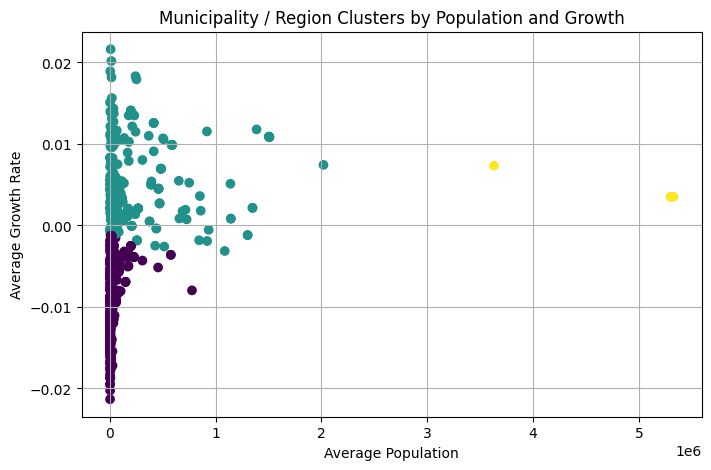

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(
    cluster_data["avg_population"],
    cluster_data["avg_growth"],
    c=cluster_data["Cluster"]
)
plt.title("Municipality / Region Clusters by Population and Growth")
plt.xlabel("Average Population")
plt.ylabel("Average Growth Rate")
plt.grid(True)
plt.show()

## Quick interpretation for the report

- The cleaned long-format CSV is saved as `finland_population_final_analysis.csv`
- The forecast CSV is saved as `finland_population_forecast_2030_2040.csv`
- If you run the same notebook in **VS Code** and **CSC**, the logic stays the same
- Results should be nearly identical if the same packages and data are used
- CSC is usually faster for larger computations, while VS Code is easier for local development